In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter1d, minimum_filter1d
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import os
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Baskerville']

In [2]:
# Baseline correction
def rubberband(x, y):
    # Find the convex hull
    v = ConvexHull(np.array(list(zip(x, y)))).vertices

    # Rotate convex hull vertices until they start from the lowest one
    v = np.roll(v, -v.argmin())
    # Leave only the ascending part
    v = v[:v.argmax()]

    # Create baseline using linear interpolation between vertices #return the baseline
    return np.interp(x, x[v], y[v])




In [300]:
ts_path = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week6/ts/Week_6_2022_08_26_16_11_43_Fluo9001_CS4A1S1_cropped_stack_ts.npy'

In [301]:
TS = np.load(ts_path)
print(TS.shape)

(189, 841)


In [307]:
TS = TS[:,2:]

In [308]:
ts_corrected = np.empty_like(TS)
# Apply baseline correction row-wise
for i in range(TS.shape[0]):
    ts_corrected[i,:] = TS[i,:] - rubberband(np.arange(TS.shape[1]), TS[i,:])

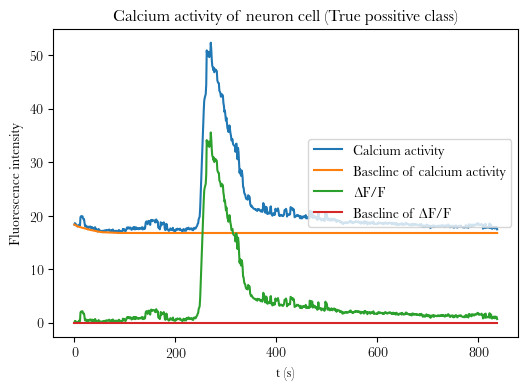

In [309]:
n= 60#255#68#61#53#44#38#21 #34
plt.figure(figsize=(6,4))
plt.title('Calcium activity of neuron cell (True possitive class)')#Calcium activity of neuron cell (True possitive class)
plt.plot(TS[n,:].T,label='Calcium activity')
plt.plot(rubberband(np.arange(TS.shape[1]), TS[n,:]),label='Baseline of calcium activity')
plt.plot(ts_corrected[n,:].T,label='ΔF/F')
plt.plot(rubberband(np.arange(ts_corrected.shape[1]), ts_corrected[n,:]),label='Baseline of ΔF/F')
plt.xlabel('t (s)',fontsize="10")
plt.ylabel('Fluorescence intensity')
plt.legend( loc='center right',fontsize="10")
#plt.savefig('/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/Time_series/figs/Dead_Neuron signal.png')
plt.show()
baseline_def = rubberband(np.arange(TS.shape[1]), TS[5,:])

In [310]:
dff = ts_corrected

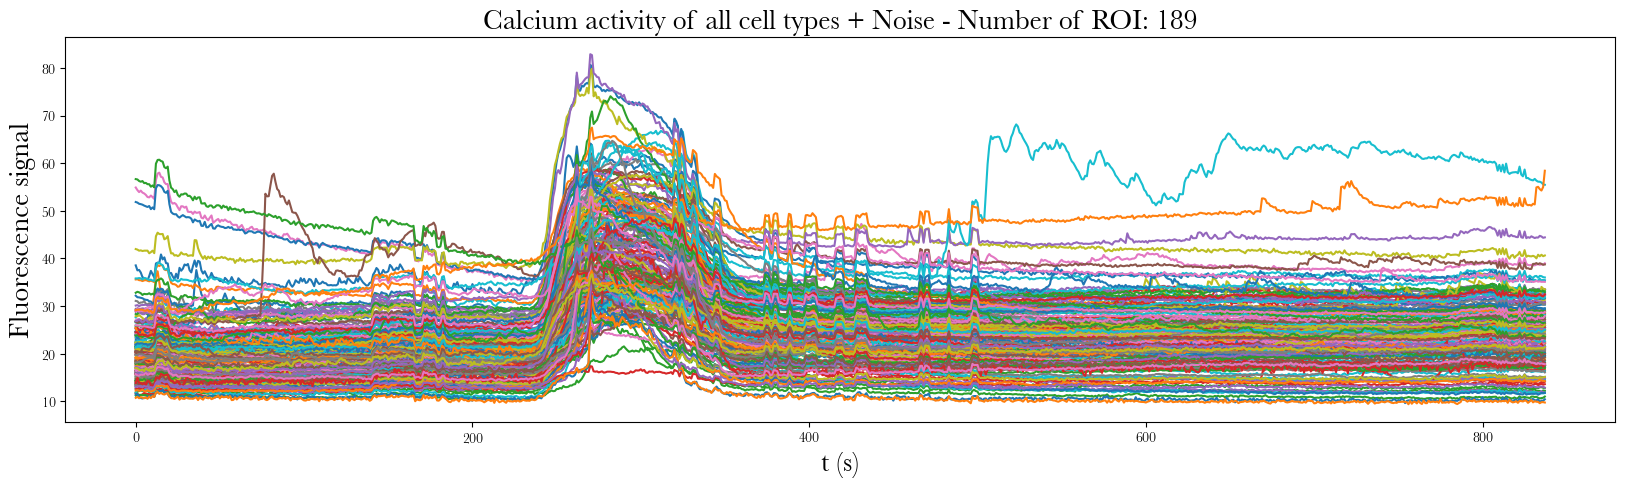

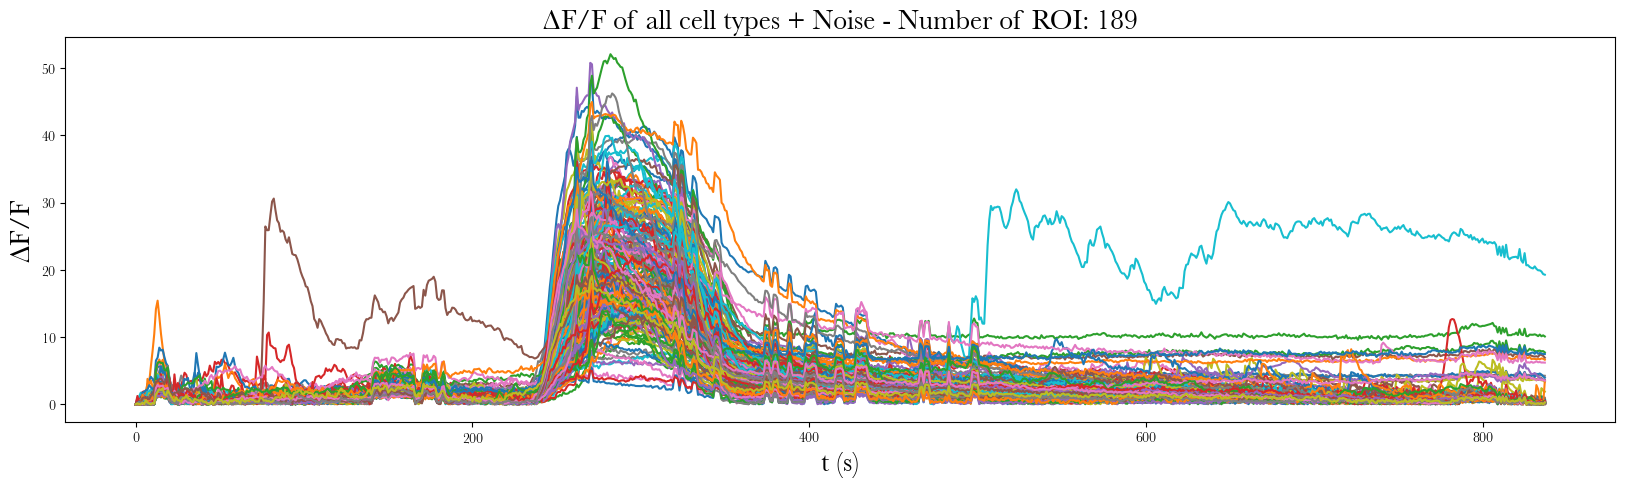

In [311]:
plt.figure(figsize=(20,5))
plt.title(f'Calcium activity of all cell types + Noise - Number of ROI: {TS.shape[0]}',fontsize="20")
plt.plot(TS[:,:].T)
plt.xlabel('t (s)',fontsize="20")
plt.ylabel('Fluorescence signal',fontsize="20")
#plt.savefig('/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/Time_series/figs/raw traces.png')
plt.show()


plt.figure(figsize=(20,5))
plt.title(f'ΔF/F of all cell types + Noise - Number of ROI: {dff.shape[0]}',fontsize="20")
plt.plot(dff[:,:].T)
plt.xlabel('t (s)',fontsize="20")
plt.ylabel(u'ΔF/F',fontsize="20")
#plt.savefig('/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/Time_series/figs/Dff traces.png')
plt.show()

In [312]:
print(np.mean(TS))
print(np.mean(dff))
print('\n')
print(np.mean(TS[:,250:400]))
print(np.mean(dff[:,250:400]))
print('\n')
print(np.max(TS[:,250:400]))
print(np.max(dff[:,250:400]))

24.76645792421796
3.7622132021771124


33.28570220796286
12.88056048759279


82.95958083832335
52.05555555555556


In [313]:
# Calculate the average values for each row
row_averages = np.mean(dff[:,250:400], axis=1)


# Calculate the global average of row averages
global_average = np.mean(dff[:,250:400])

# Find the indices of rows with average values below the global average
rows_to_delete = np.where(row_averages < 0.5*global_average)[0]
#rows_to_delete = np.where(row_averages > 4*global_average)[0]
# Delete the rows from the data_matrix
filtered_dff = np.delete(ts_corrected, rows_to_delete, axis=0)
# Find the indices of rows with average values above the global average

print(filtered_dff.shape)
filtered_dff.shape[0]/TS.shape[0]

(176, 838)


0.9312169312169312

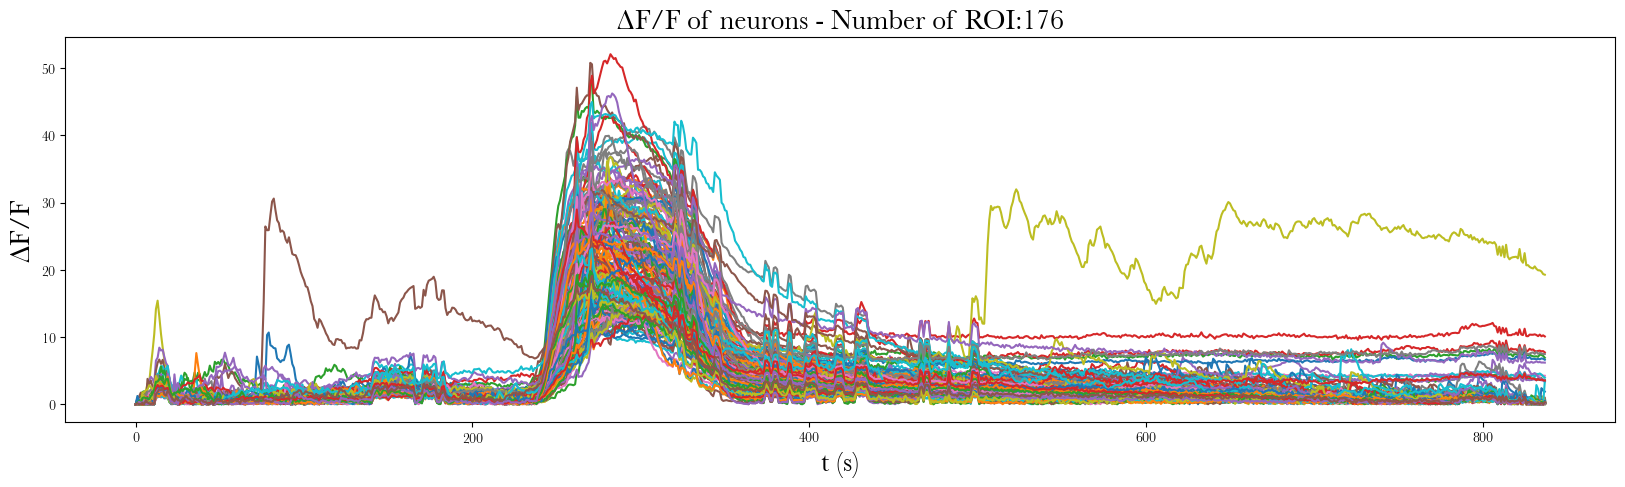

In [314]:

plt.figure(figsize=(20,5))
plt.title(f'ΔF/F of neurons - Number of ROI:{filtered_dff.shape[0]}',fontsize="20")
plt.plot(filtered_dff[:,:].T)
plt.xlabel('t (s)',fontsize="20")
plt.ylabel(u'ΔF/F',fontsize="20")
#plt.savefig('/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/Time_series/figs/filtered Dff traces.png')
plt.show()

In [319]:
init_dff = filtered_dff[:,0:200]
init_dff.shape

(176, 200)

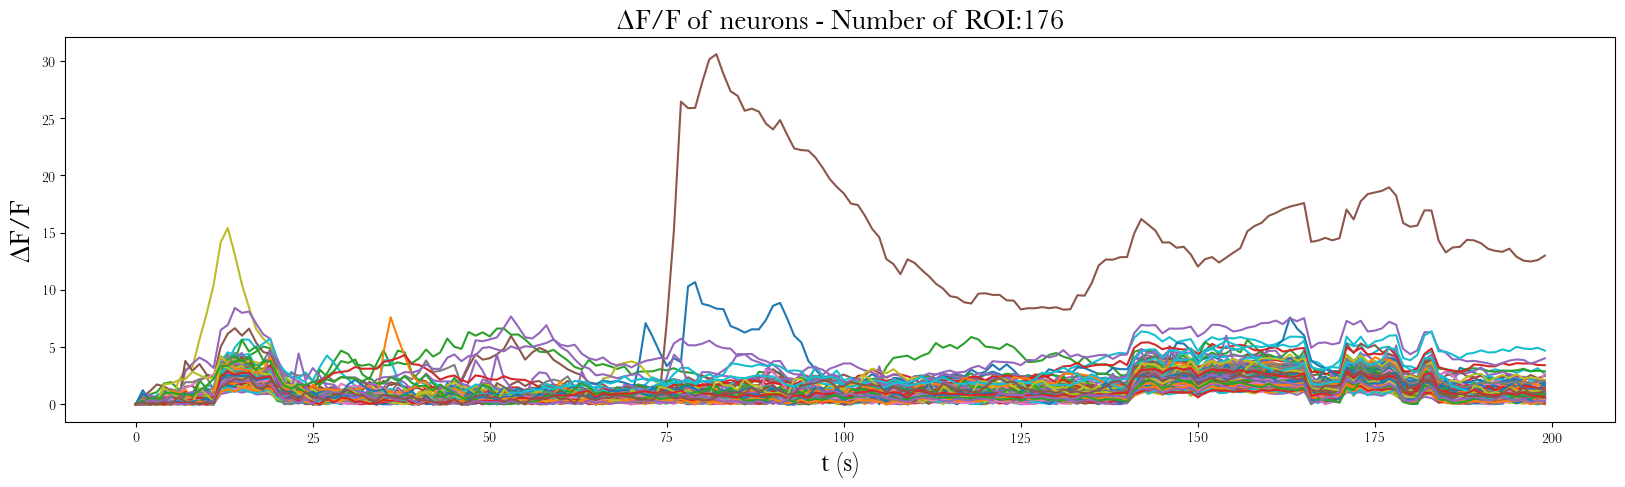

In [320]:
plt.figure(figsize=(20,5))
plt.title(f'ΔF/F of neurons - Number of ROI:{init_dff.shape[0]}',fontsize="20")
plt.plot(init_dff[:,:].T)
plt.xlabel('t (s)',fontsize="20")
plt.ylabel(u'ΔF/F',fontsize="20")
#plt.savefig('/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/Time_series/figs/init_ts Dff traces.png')
plt.show()

In [321]:
Base_name = os.path.basename(ts_path)
base_name, _ = os.path.splitext(Base_name[:])
print(base_name)

Week_6_2022_08_26_16_11_43_Fluo9001_CS4A1S1_cropped_stack_ts


In [298]:
output_dir = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2/week6/ts_corrected_dff"
output_path = os.path.join(output_dir, base_name + "_init_dff.npy")
np.save(output_path, init_dff)
output_path = os.path.join(output_dir, base_name + "_filtered_dff.npy")
np.save(output_path, filtered_dff)
output_path = os.path.join(output_dir, base_name + "_dff.npy")
np.save(output_path, dff)
# Save the Fluo_ts array to the .npy file


In [299]:
filtered_dff.shape[0]/TS.shape[0]

0.8044692737430168